<a href="https://colab.research.google.com/github/aeroivop/predictive-maintenance-engine/blob/main/predictive_maintenance_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Descargando telemetría global de la NASA...
2. Aplicando limpieza Z-Score por regímenes de vuelo...
3. Separando Entrenamiento y Examen, y entrenando modelo...
4. Generando Dashboard de Validación...


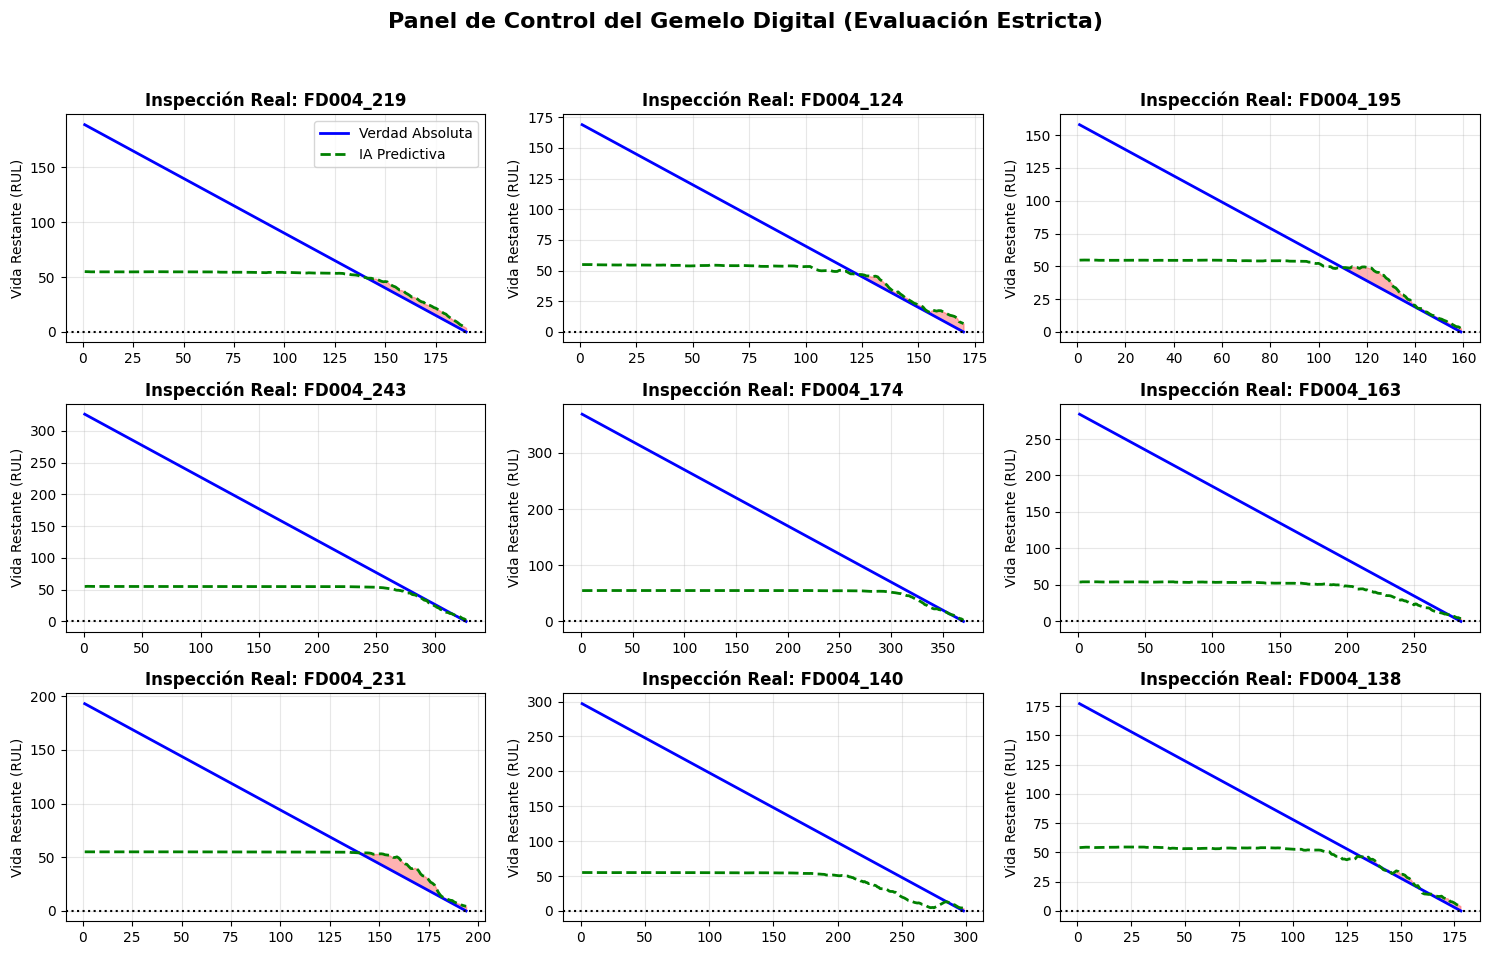

In [15]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib # Librería estándar para guardar modelos en disco

# ==============================================================================
# BLOQUE 1: INGESTIÓN Y PREPROCESAMIENTO (El Filtro Termodinámico)
# ==============================================================================
print("1. Descargando telemetría global de la NASA...")
base_url = "https://huggingface.co/datasets/penikmatrumput/nasa-cmapss-rul/resolve/main/"
archivos = ["train_FD001.csv", "train_FD002.csv", "train_FD003.csv", "train_FD004.csv"]

lista_df = []
for f in archivos:
    df_temp = pd.read_csv(base_url + f)
    # Crear ID Único (Ej: FD004_217) para evitar que se mezclen motores de distintos archivos
    nombre_ds = f.split('_')[1].split('.')[0]
    df_temp['ID_Unico'] = nombre_ds + "_" + df_temp['unit_number'].astype(str)
    lista_df.append(df_temp)

df_global = pd.concat(lista_df, ignore_index=True)
df_global = df_global.rename(columns={'time_in_cycles': 'Ciclo_Vuelo', 'RUL': 'RUL_Real'})

def limpiar_ruido_atmosferico(data):
    """
    Limita el RUL basándose en física (60 ciclos) y normaliza los sensores
    agrupando por régimen de vuelo para eliminar el efecto de la altitud y velocidad.
    """
    print("2. Aplicando limpieza Z-Score por regímenes de vuelo...")
    # Límite físico
    data['RUL_Target'] = data['RUL_Real'].clip(upper=60)

    # Identificación del régimen de vuelo
    ajustes = ['op_setting_1', 'op_setting_2', 'op_setting_3']
    data['Regimen'] = data[ajustes].round(1).astype(str).sum(axis=1)

    # Normalización sensor a sensor
    sensores = [f'sensor_{i}' for i in range(1, 22)]
    for s in sensores:
        if data[s].std() > 0.001:
            data[s] = data.groupby('Regimen')[s].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
        else:
            data[s] = 0
    return data, sensores

df_limpio, columnas_sensores = limpiar_ruido_atmosferico(df_global)

# ==============================================================================
# BLOQUE 2: ENTRENAMIENTO Y EXPORTACIÓN
# ==============================================================================
print("3. Separando Entrenamiento y Examen, y entrenando modelo...")

# 🛑 LA CORRECCIÓN: Separamos estrictamente la flota
# Los motores del 1 al 80 de cada archivo van para entrenamiento.
# Los motores del 81 en adelante de cada archivo se guardan bajo llave para el examen.
df_entrenamiento = df_limpio[df_limpio['unit_number'] <= 80]
df_examen = df_limpio[df_limpio['unit_number'] > 80]

X_train = df_entrenamiento[columnas_sensores]
y_train = df_entrenamiento['RUL_Target']

# Penalizamos x10 si fallamos cuando el motor está a punto de morir
pesos_seguridad = np.where(y_train <= 25, 10.0, 1.0)

modelo_maestro = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    tree_method='hist'
)

# Entrenamos SOLO con los datos de entrenamiento
modelo_maestro.fit(X_train, y_train, sample_weight=pesos_seguridad)

# Guardar el modelo sin trampas
# modelo_maestro.save_model("cerebro_turbofan_universal.json")
# print("✅ ¡Modelo riguroso guardado en disco!")

# ==============================================================================
# BLOQUE 3: EL GEMELO DIGITAL (Examen Real)
# ==============================================================================
print("4. Generando Dashboard de Validación...")
# Filtramos solo motores del FD004, pero AHORA desde df_examen (nunca vistos por la IA)
motores_fd004_examen = df_examen[df_examen['ID_Unico'].str.contains('FD004')]['ID_Unico'].unique()
motores_seleccionados = np.random.choice(motores_fd004_examen, 9, replace=False)

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
axs = axs.flatten()

for i, m_id in enumerate(motores_seleccionados):
    # Cogemos los datos del motor desde df_examen
    datos_motor = df_examen[df_examen['ID_Unico'] == m_id]

    prediccion_bruta = modelo_maestro.predict(datos_motor[columnas_sensores])
    prediccion_segura = pd.Series(prediccion_bruta).rolling(window=12, min_periods=1).mean() - 5

    axs[i].plot(datos_motor['Ciclo_Vuelo'], datos_motor['RUL_Real'], color='blue', linewidth=2, label='Verdad Absoluta')
    axs[i].plot(datos_motor['Ciclo_Vuelo'], prediccion_segura, color='green', linestyle='--', linewidth=2, label='IA Predictiva')

    axs[i].fill_between(datos_motor['Ciclo_Vuelo'], prediccion_segura, datos_motor['RUL_Real'],
                        where=(prediccion_segura.values > datos_motor['RUL_Real'].values), color='red', alpha=0.3)

    axs[i].axhline(y=0, color='black', linewidth=1.5, linestyle=':')
    axs[i].set_title(f"Inspección Real: {m_id}", fontweight='bold')
    axs[i].set_ylabel("Vida Restante (RUL)")
    axs[i].grid(alpha=0.3)
    if i == 0: axs[i].legend()

plt.suptitle("Panel de Control del Gemelo Digital (Evaluación Estricta)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()